## Introduction: This project visualises earthquake activity in the Santorini region of Greece in 2025. 

Inspired by increased seismic activity observed in the area, the analysis maps earthquake locations and performs aggregations to provide an overview of the recent seismic trends

Source = https://earthquake.usgs.gov/fdsnws/event/1/

In [1]:
import requests
import pandas as pd
import folium
from folium.plugins import HeatMap

# Below imports/ code is to display outputs in full, can be unmuted when necessary
#pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)
#pd.set_option('display.float_format', lambda x: '%.3f' % x)
#pd.set_option('display.expand_frame_repr', False)
#pd.set_option('display.width', 500)

In [2]:
start_time = "2025-01-01"   # beginning of January 2025
end_time   = "2025-04-30"   # end of April 2025
min_magnitude = 3
latitude = 39.1458
longitude = 34.1614
max_radius_km = 1500

url = requests.get(
    f"https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson"
    f"&starttime={start_time}&endtime={end_time}"
    f"&minmagnitude={min_magnitude}"
    f"&latitude={latitude}&longitude={longitude}&maxradiuskm={max_radius_km}"
)

dataset = url.json()

In [3]:
url

<Response [200]>

In [4]:
type(dataset)

dict

In [5]:
#dataset

In [6]:
# 1. Access the metadata:
metadata = dataset['metadata']
print(f"Data source: {metadata['title']}")
print(f"Number of earthquakes: {metadata['count']}")

Data source: USGS Earthquakes
Number of earthquakes: 461


In [7]:
# 2. Access the list of features:
earthquakes = dataset['features']

In [8]:
# 3. Create lists to store the extracted data
magnitudes = []
places = []
longitudes = []
latitudes = []
depths = []
timestamps = []

In [9]:
# 4. Iterate through the earthquakes and extract information:
for earthquake in earthquakes:
    properties = earthquake['properties']
    geometry = earthquake['geometry']
    magnitude = properties['mag']
    place = properties['place']
    longitude, latitude, depth = geometry['coordinates']  # Unpack the coordinates
    timestamp_ms = properties['time']

    # Convert timestamp to datetime object (it's in milliseconds)
    import datetime
    timestamp = datetime.datetime.fromtimestamp(timestamp_ms / 1000)

    magnitudes.append(magnitude)
    places.append(place)
    longitudes.append(longitude)
    latitudes.append(latitude)
    depths.append(depth)
    timestamps.append(timestamp)


In [10]:
# Creating a Pandas DataFrame so we can use Pandas library for analysis
data = {
    'Magnitude': magnitudes,
    'Place': places,
    'Longitude': longitudes,
    'Latitude': latitudes,
    'Depth': depths,
    'Timestamp': timestamps
}
df = pd.DataFrame(data)
df.head()

,Magnitude,Place,Longitude,Latitude,Depth,Timestamp
0,4.1,"58 km SW of Lithakiá, Greece",20.3842,37.3287,35.566,2025-04-29 22:52:18.369
1,4.7,"9 km W of Doğanyol, Turkey",38.9257,38.3165,11.847,2025-04-28 04:09:37.895
2,4.3,"19 km SSW of Kumburgaz, Turkey",28.4298,40.8537,10.000,2025-04-26 03:33:16.251
3,4.6,"20 km N of Simav, Turkey",28.9731,39.2734,10.000,2025-04-25 17:20:02.976
4,4.4,"29 km N of Simav, Turkey",28.9184,39.3466,10.000,2025-04-25 14:23:44.743


In [11]:
# Would like to use the folium library to visualise earthquakes that happened around the Santorini and surrounds. Turkey had a major earthquake in 2023, I also wanted see the activity in Turkey region as well.

turkey_coord = [39, 35]
turkey_map_normal = folium.Map(location=turkey_coord, zoom_start=5.5)
HeatMap(data=df[['Latitude', 'Longitude', 'Magnitude']], radius=15).add_to(turkey_map_normal)

for index, row in df.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=row['Magnitude']/2,
        color='red',
        fill_color='red').add_to(turkey_map_normal)

turkey_map_normal

In [12]:
# I would like to add a new column called "Country" to see if I can use it for some aggregations. First, I'll create a function to split the text for me 

def extract_country(place_string):
    """
    Extracts the country name from a place string like "28 km NE of Firá, Greece".
    Handles cases where the string might be in a different format.
    """
    try:
        country = place_string.split(', ')[-1]  # Split at ", " and take the last part
        return country
    except IndexError:
        return "Unknown"  # Handle cases without a comma
    except:
        return "Error"  # Catch other potential errors

In [13]:
# Apply the function to the 'Place' column to create a new 'Country' column
df['Country'] = df['Place'].apply(extract_country)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461 entries, 0 to 460
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Magnitude  461 non-null    float64       
 1   Place      461 non-null    object        
 2   Longitude  461 non-null    float64       
 3   Latitude   461 non-null    float64       
 4   Depth      461 non-null    float64       
 5   Timestamp  461 non-null    datetime64[ns]
 6   Country    461 non-null    object        
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 25.3+ KB


In [15]:
df.head()

,Magnitude,Place,Longitude,Latitude,Depth,Timestamp,Country
0,4.1,"58 km SW of Lithakiá, Greece",20.3842,37.3287,35.566,2025-04-29 22:52:18.369,Greece
1,4.7,"9 km W of Doğanyol, Turkey",38.9257,38.3165,11.847,2025-04-28 04:09:37.895,Turkey
2,4.3,"19 km SSW of Kumburgaz, Turkey",28.4298,40.8537,10.000,2025-04-26 03:33:16.251,Turkey
3,4.6,"20 km N of Simav, Turkey",28.9731,39.2734,10.000,2025-04-25 17:20:02.976,Turkey
4,4.4,"29 km N of Simav, Turkey",28.9184,39.3466,10.000,2025-04-25 14:23:44.743,Turkey


In [16]:
df.groupby("Country")['Magnitude'].agg(['min', 'max', 'count'])

,min,max,count
Country,,,
Armenia,4.4,4.4,1
Azerbaijan,4.3,4.3,1
Cyprus,3.1,3.1,1
Georgia,3.0,4.1,2
Greece,3.9,5.3,406
Iran,4.0,5.1,8
Italy,4.3,4.3,1
Montenegro,4.3,4.3,1
Romania,4.3,4.3,1


In [17]:
#?df.groupby

## Some feature engineering 

In [18]:
# Extracting some date-time features to be used for aggregations

# Extract the Month
df['Month'] = df['Timestamp'].dt.month_name() 

# Extract the Hour to create 'TimeOfDay'
df['Hour'] = df['Timestamp'].dt.hour

In [19]:
# Want to create this function to create a new column which would show the time of the day
def categorize_time(hour):
    """Categorizes the hour of the day into Morning, Afternoon, Evening, or Night."""
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 24:
        return 'Evening'
    else:
        return 'Night'  # Covers 0-6

In [20]:
df['TimeOfDay'] = df['Hour'].apply(categorize_time)

In [21]:
df.head()

,Magnitude,Place,Longitude,Latitude,Depth,Timestamp,Country,Month,Hour,TimeOfDay
0,4.1,"58 km SW of Lithakiá, Greece",20.3842,37.3287,35.566,2025-04-29 22:52:18.369,Greece,April,22,Evening
1,4.7,"9 km W of Doğanyol, Turkey",38.9257,38.3165,11.847,2025-04-28 04:09:37.895,Turkey,April,4,Night
2,4.3,"19 km SSW of Kumburgaz, Turkey",28.4298,40.8537,10.000,2025-04-26 03:33:16.251,Turkey,April,3,Night
3,4.6,"20 km N of Simav, Turkey",28.9731,39.2734,10.000,2025-04-25 17:20:02.976,Turkey,April,17,Afternoon
4,4.4,"29 km N of Simav, Turkey",28.9184,39.3466,10.000,2025-04-25 14:23:44.743,Turkey,April,14,Afternoon


In [22]:
# Most frequent month for earthquakes - February 2025 was the highest amount of earthquakes
monthly_counts = df['Month'].value_counts()
print("\nEarthquake counts per month:")
print(monthly_counts)


Earthquake counts per month:
Month
February    373
April        31
March        30
January      27
Name: count, dtype: int64


In [23]:
# Most frequent time of day for earthquakes - Evening time is when the earthquakes happen more 
time_of_day_counts = df['TimeOfDay'].value_counts()
print("\nEarthquake counts per time of day:")
print(time_of_day_counts)


Earthquake counts per time of day:
TimeOfDay
Evening      163
Afternoon    127
Night         86
Morning       85
Name: count, dtype: int64


In [24]:
# Some descriptive insights from the depth column
df['Depth'].describe()

count    461.000000
mean      12.831401
std       13.212789
min        5.618000
25%       10.000000
50%       10.000000
75%       10.000000
max      150.935000
Name: Depth, dtype: float64

## Want to create some visualisations, such as line plots and folium maps

In [25]:
# Changing the index to the Timestamp column which would then allow us to plot some line charts
df_time = df.set_index("Timestamp")
df_time.head()

,Magnitude,Place,Longitude,Latitude,Depth,Country,Month,Hour,TimeOfDay
Timestamp,,,,,,,,,
2025-04-29 22:52:18.369,4.1,"58 km SW of Lithakiá, Greece",20.3842,37.3287,35.566,Greece,April,22,Evening
2025-04-28 04:09:37.895,4.7,"9 km W of Doğanyol, Turkey",38.9257,38.3165,11.847,Turkey,April,4,Night
2025-04-26 03:33:16.251,4.3,"19 km SSW of Kumburgaz, Turkey",28.4298,40.8537,10.000,Turkey,April,3,Night
2025-04-25 17:20:02.976,4.6,"20 km N of Simav, Turkey",28.9731,39.2734,10.000,Turkey,April,17,Afternoon
2025-04-25 14:23:44.743,4.4,"29 km N of Simav, Turkey",28.9184,39.3466,10.000,Turkey,April,14,Afternoon


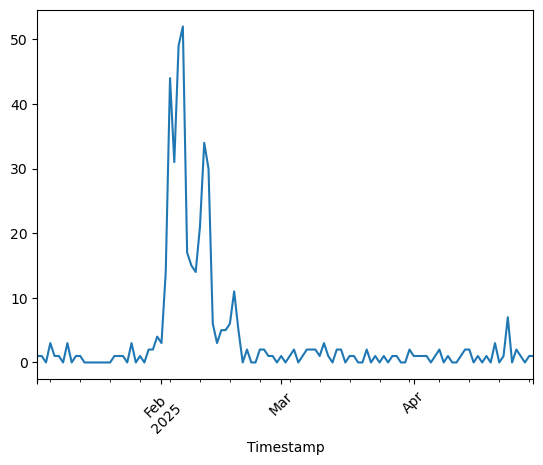

In [26]:
import matplotlib.pyplot as plt
#fig, ax = plt.subplots()
df_time.resample('D').size().plot()  # Counts the number of events per day
plt.xticks(rotation=45)
plt.show()

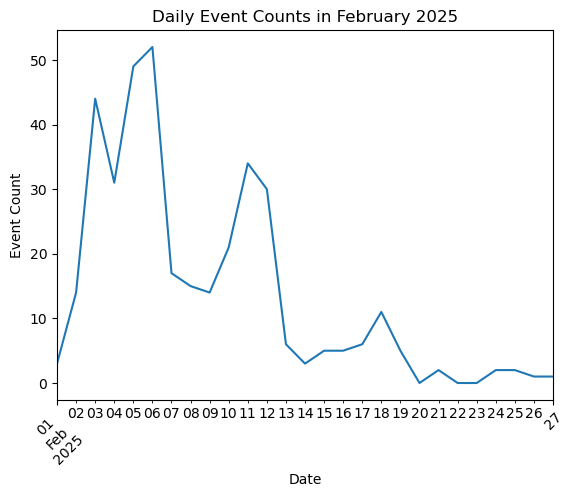

In [27]:
# It seems like there is a lot of activity in February, so let's zoom in a bit more

# Filter for February 2025
df_february = df[(df['Timestamp'].dt.year == 2025) & (df['Timestamp'].dt.month == 2)]

# Aggregate daily event counts
df_february.resample('D', on='Timestamp').size().plot()

# Improve x-axis formatting
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Event Count')
plt.title('Daily Event Counts in February 2025')
plt.show()


In [28]:
df['Place'].value_counts()

Place
21 km NE of Firá, Greece           15
25 km NE of Firá, Greece           11
26 km NE of Firá, Greece            9
23 km NE of Firá, Greece            8
20 km NE of Firá, Greece            8
                                   ..
8 km N of Cașoca, Romania           1
24 km E of Íos, Greece              1
8 km ENE of Gornoye Loo, Russia     1
27 km E of Íos, Greece              1
48 km SW of Palaióchora, Greece     1
Name: count, Length: 261, dtype: int64

In [29]:
# Count occurrences of each place and get the top 20
top_places = df['Place'].value_counts().head(20).index
df_top_places = df[df['Place'].isin(top_places)]
df_top_places

,Magnitude,Place,Longitude,Latitude,Depth,Timestamp,Country,Month,Hour,TimeOfDay
33,4.5,"18 km NE of Firá, Greece",25.5614,36.5518,10.000,2025-03-28 04:51:48.622,Greece,March,4,Night
34,4.0,"21 km ENE of Mesariá, Greece",25.6665,36.4836,10.000,2025-03-27 12:15:45.476,Greece,March,12,Afternoon
36,4.2,"30 km SW of Amorgós, Greece",25.6954,36.6067,9.866,2025-03-23 00:02:34.256,Greece,March,0,Night
61,4.0,"20 km NE of Firá, Greece",25.5829,36.5575,11.684,2025-02-27 09:12:46.940,Greece,February,9,Morning
63,3.9,"25 km NE of Firá, Greece",25.6142,36.6017,10.000,2025-02-25 11:24:49.387,Greece,February,11,Morning
...,...,...,...,...,...,...,...,...,...,...
416,4.3,"23 km NE of Firá, Greece",25.6185,36.5684,10.000,2025-02-03 00:32:30.092,Greece,February,0,Night
417,4.8,"28 km SW of Amorgós, Greece",25.6674,36.6529,10.000,2025-02-02 23:55:42.204,Greece,February,23,Evening
420,4.4,"29 km NE of Firá, Greece",25.6257,36.6300,10.000,2025-02-02 22:41:27.490,Greece,February,22,Evening
421,4.4,"25 km NE of Firá, Greece",25.6267,36.5915,10.000,2025-02-02 22:35:33.679,Greece,February,22,Evening


In [30]:
# Now I would like to zoom in to the Greece region on a Folium map, tooltips showing the date and the magnitute of the earthquake
from folium.plugins import MarkerCluster

# Create a base map centered on Greece
m = folium.Map(location=[df['Latitude'].mean(), df['Longitude'].mean()], zoom_start=8)

# Add individual markers
for _, row in df_top_places.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"Place: {row['Place']}<br>Magnitude: {row['Magnitude']}<br>Timestamp: {row['Timestamp']}",
        tooltip=f"Date: {row['Timestamp'].strftime('%Y-%m-%d %H:%M:%S')} | Mag: {row['Magnitude']}"  # Tooltip shows date & magnitude
    ).add_to(m)

# Show map
m


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461 entries, 0 to 460
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Magnitude  461 non-null    float64       
 1   Place      461 non-null    object        
 2   Longitude  461 non-null    float64       
 3   Latitude   461 non-null    float64       
 4   Depth      461 non-null    float64       
 5   Timestamp  461 non-null    datetime64[ns]
 6   Country    461 non-null    object        
 7   Month      461 non-null    object        
 8   Hour       461 non-null    int32         
 9   TimeOfDay  461 non-null    object        
dtypes: datetime64[ns](1), float64(4), int32(1), object(4)
memory usage: 34.3+ KB


## Conclusion:

In early 2025, it seems like there was a lot happening in the same region of Greece. I would like to retreive more data and build a machine learning model to predict potential earthquakes in the future.

In [32]:
# I will convert this data frame to a csv for future use
# df.to_csv("Santorini2025.csv")